# Nonlinear Relationships

In [86]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')
import pandas as pd

In [87]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame# we intensionally loaded the boston dataset because the dataset is removed in the 1.2 version of sklearn

In [88]:
df= data.drop('MEDV', axis=1)

In [89]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


In [90]:
y=boston.target

## Brief introduction to Decision Tree

In [91]:
from sklearn.tree import DecisionTreeRegressor

In [92]:
X=df[['LSTAT']].values

In [93]:
tree= DecisionTreeRegressor(max_depth=5)

In [94]:
tree.fit(X,y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [95]:
sort_idx=X.flatten().argsort()

Text(0, 0.5, 'MEDV')

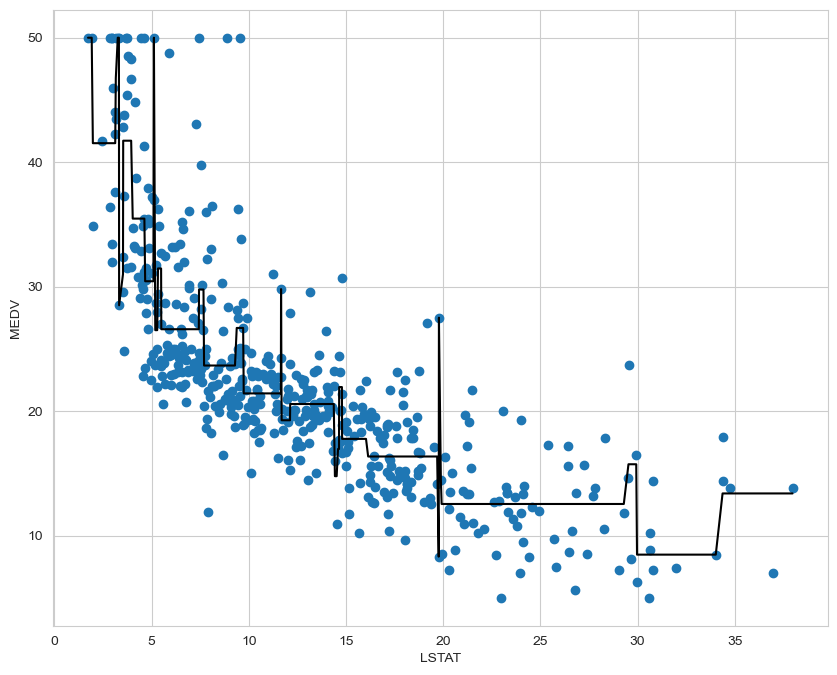

In [96]:
plt.figure(figsize=(10,8))
plt.scatter(X[sort_idx],y[sort_idx])
plt.plot(X[sort_idx],tree.predict(X[sort_idx]),color='k')
plt.xlabel("LSTAT")
plt.ylabel("MEDV")

## Brief Introduction to Random Forest

In [97]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [98]:
X=df.values

In [99]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [100]:
from sklearn.ensemble import RandomForestRegressor

In [101]:
forest=RandomForestRegressor(n_estimators=500,criterion='squared_error',
                             random_state=42,n_jobs=-1)

In [102]:
forest.fit(X_train,y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [103]:
y_train_pred=forest.predict(X_train)

In [104]:
y_test_pred=forest.predict(X_test)

In [105]:
print("Squared_error train:{0:.4f},test:{1:.4f}".\
      format(mean_squared_error(y_train,y_train_pred),
            mean_squared_error(y_test,y_test_pred)))

Squared_error train:1.8753,test:9.3256


In [106]:
print("R^2 train:{0:.4f},test:{1:.4f}".\
      format(r2_score(y_train,y_train_pred),
            r2_score(y_test,y_test_pred)))

R^2 train:0.9787,test:0.8748


## Brief introduction to AdaBoost

In [107]:
from sklearn.ensemble import AdaBoostRegressor

In [108]:
ada=AdaBoostRegressor(DecisionTreeRegressor(max_depth=4),
                      n_estimators=500,random_state=42)

In [109]:
ada.fit(X_train,y_train)

,estimator,DecisionTreeR...r(max_depth=4)
,n_estimators,500
,learning_rate,1.0
,loss,'linear'
,random_state,42
,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [110]:
y_train_pred=ada.predict(X_train)

In [111]:
y_test_pred=ada.predict(X_test)

In [112]:
print("Squared_error train:{0:.4f},test:{1:.4f}".\
      format(mean_squared_error(y_train,y_train_pred),
            mean_squared_error(y_test,y_test_pred)))

Squared_error train:4.4567,test:13.2427


In [113]:
print("R^2 train:{0:.4f},test:{1:.4f}".\
      format(r2_score(y_train,y_train_pred),
            r2_score(y_test,y_test_pred)))

R^2 train:0.9493,test:0.8223


# Feature Importance
##  According to AdaBoost

In [114]:
ada.feature_importances_

array([0.03284169, 0.0017967 , 0.01146074, 0.00209209, 0.03897159,
       0.24219268, 0.01057968, 0.13055771, 0.01554554, 0.02348895,
       0.04072215, 0.02430303, 0.42544745])

In [115]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='object')

In [116]:
result=pd.DataFrame(ada.feature_importances_,df.columns)
result.columns=["feature"]

In [117]:
result.sort_values(by='feature',ascending=False)

,feature
LSTAT,0.425447
RM,0.242193
DIS,0.130558
PTRATIO,0.040722
NOX,0.038972
CRIM,0.032842
B,0.024303
TAX,0.023489
RAD,0.015546
INDUS,0.011461


<Axes: >

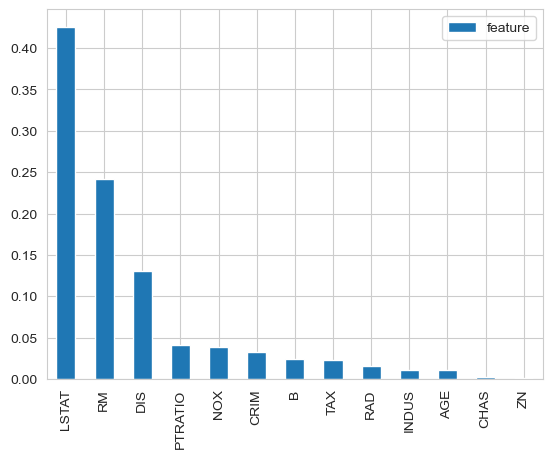

In [118]:
result.sort_values(by='feature',ascending=False).plot(kind='bar')

## According to Random Forest

In [119]:
forest.feature_importances_

array([0.03204822, 0.00160483, 0.00700703, 0.00125804, 0.01475089,
       0.40389139, 0.01410918, 0.06287534, 0.00515063, 0.01197446,
       0.01821116, 0.01241787, 0.41470096])

<Axes: >

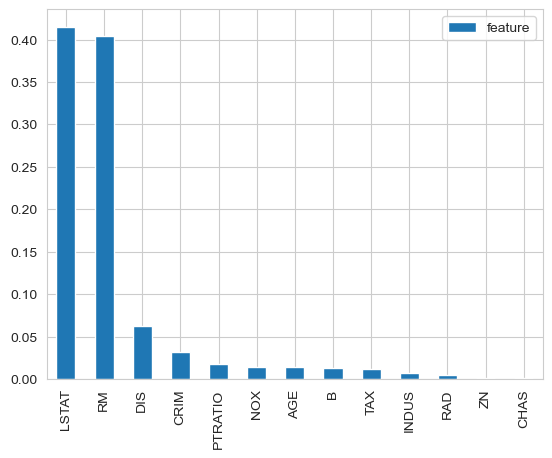

In [120]:
result=pd.DataFrame(forest.feature_importances_,df.columns)
result.columns=["feature"]
result.sort_values(by='feature',ascending=False).plot(kind='bar')

# Exercise

In [121]:
tree=DecisionTreeRegressor(max_depth=3)
tree.fit(X_train,y_train)

y_train_pred=tree.predict(X_train)
y_test_pred=tree.predict(X_test)

In [122]:
print("Mean squared Error train:{0:.4f},test:{1:.4f}".\
      format(mean_squared_error(y_train,y_train_pred),
             mean_squared_error(y_test,y_test_pred)))

Mean squared Error train:15.3680,test:19.1073


In [123]:
print("R^2 train:{0:.4f},test:{1:.4f}".\
      format(r2_score(y_train,y_train_pred),
             r2_score(y_test,y_test_pred)))

R^2 train:0.8252,test:0.7436


<Axes: >

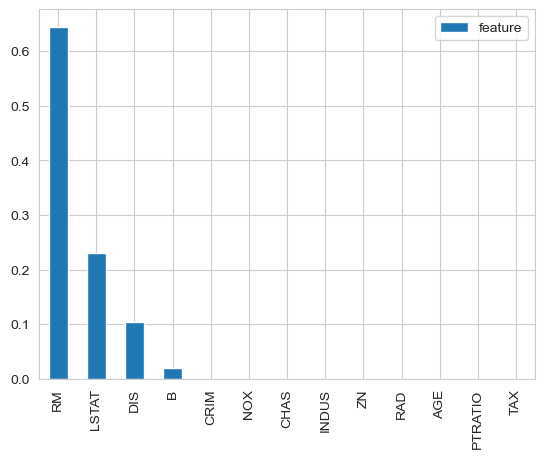

In [124]:
result=pd.DataFrame(tree.feature_importances_,df.columns)
result.columns=['feature']
result.sort_values(by='feature',ascending=False).plot(kind='bar')